In [1]:
print("Retail Sales Forecasting Project Started 🚀")


Retail Sales Forecasting Project Started 🚀


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [6]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Create date range (1 year daily data)
dates = pd.date_range(start="2023-01-01", end="2023-12-31")

stores = ["Store_1", "Store_2", "Store_3"]
products = ["Product_A", "Product_B", "Product_C", "Product_D"]

data = []

for store in stores:
    for product in products:
        base_demand = np.random.randint(20, 100)

        for date in dates:

            # weekend effect
            weekend_boost = 1.2 if date.weekday() >= 5 else 1

            # random noise
            noise = np.random.normal(0, 5)

            # base sales
            sales = base_demand * weekend_boost + noise

            # promotion effect
            promo = np.random.choice([0, 1], p=[0.8, 0.2])
            if promo == 1:
                sales *= 1.3

            sales = max(0, int(sales))

            data.append([store, product, date, sales, promo])

df = pd.DataFrame(data, columns=["Store", "Product", "Date", "Sales", "Promo"])

df.head()

,Store,Product,Date,Sales,Promo
0,Store_1,Product_A,2023-01-01,79,0
1,Store_1,Product_A,2023-01-02,72,0
2,Store_1,Product_A,2023-01-03,72,0
3,Store_1,Product_A,2023-01-04,76,0
4,Store_1,Product_A,2023-01-05,68,0


In [7]:
df.shape

(4380, 5)

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Store    4380 non-null   object        
 1   Product  4380 non-null   object        
 2   Date     4380 non-null   datetime64[ns]
 3   Sales    4380 non-null   int64         
 4   Promo    4380 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 171.2+ KB


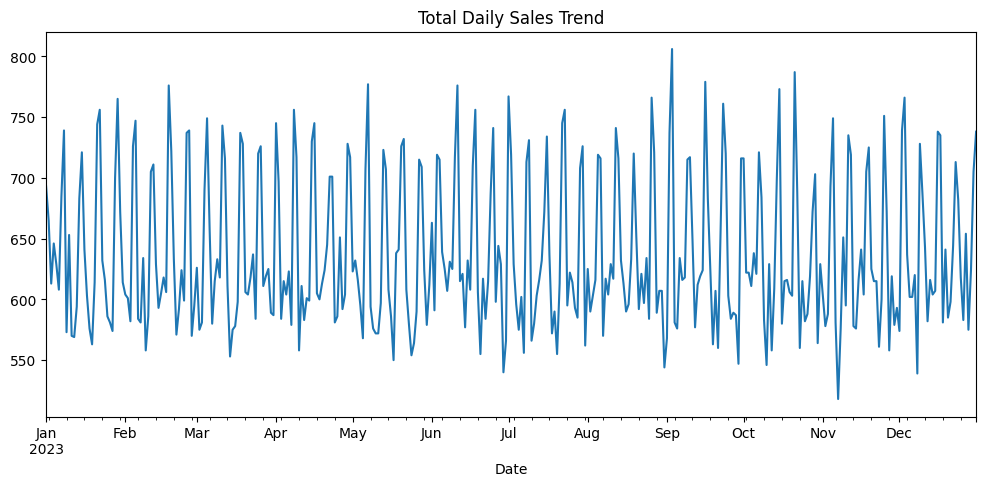

In [9]:
plt.figure(figsize=(12,5))
df.groupby("Date")["Sales"].sum().plot()
plt.title("Total Daily Sales Trend")
plt.show()

In [10]:
df["Sales"].describe()

count    4380.000000
mean       53.074429
std        22.390469
min        12.000000
25%        36.000000
50%        49.000000
75%        66.000000
max       142.000000
Name: Sales, dtype: float64

In [11]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

Product
Product_B    81137
Product_A    61365
Product_D    54494
Product_C    35470
Name: Sales, dtype: int64

In [12]:
df.groupby("Store")["Sales"].sum().sort_values(ascending=False)

Store
Store_3    90003
Store_1    83132
Store_2    59331
Name: Sales, dtype: int64

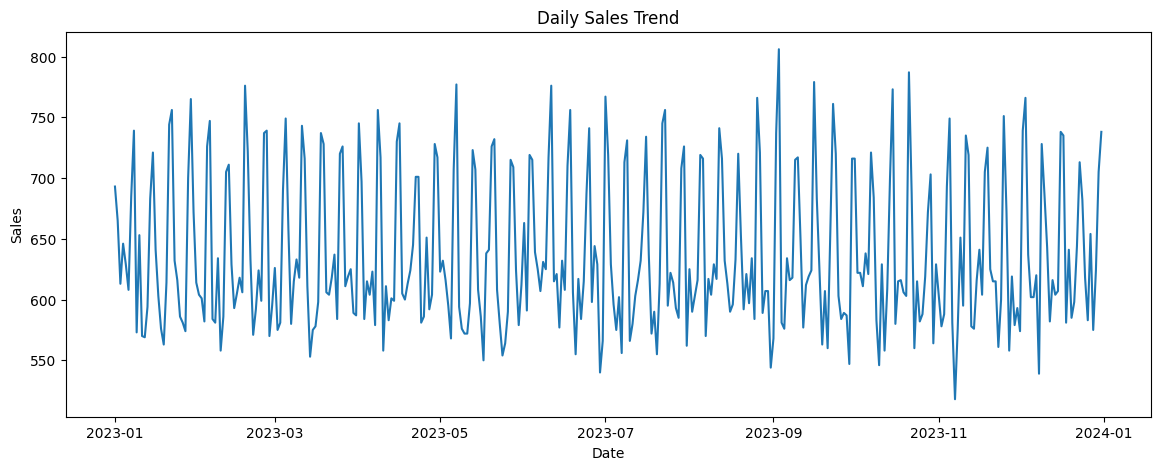

In [13]:
import matplotlib.pyplot as plt

daily_sales = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(14,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [14]:
df.groupby("Promo")["Sales"].mean()

Promo
0    50.245154
1    64.456422
Name: Sales, dtype: float64

In [19]:
df = df.sort_values(["Store", "Product", "Date"])

In [20]:
df["Sales_Lag_1"] = df.groupby(["Store", "Product"])["Sales"].shift(1)
df["Sales_Lag_7"] = df.groupby(["Store", "Product"])["Sales"].shift(7)

In [21]:
df["Rolling_Mean_7"] = df.groupby(["Store", "Product"])["Sales"].transform(lambda x: x.shift(1).rolling(7).mean())

In [22]:
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month

In [23]:
df.head()


,Store,Product,Date,Sales,Promo,Sales_Lag_1,Sales_Lag_7,Rolling_Mean_7,DayOfWeek,Month
0,Store_1,Product_A,2023-01-01,79,0,NaN,NaN,NaN,6,1
1,Store_1,Product_A,2023-01-02,72,0,79.0,NaN,NaN,0,1
2,Store_1,Product_A,2023-01-03,72,0,72.0,NaN,NaN,1,1
3,Store_1,Product_A,2023-01-04,76,0,72.0,NaN,NaN,2,1
4,Store_1,Product_A,2023-01-05,68,0,76.0,NaN,NaN,3,1


In [24]:
df_clean = df.dropna()

In [25]:
df_clean.shape

(4296, 10)

In [26]:
df_clean.head()

,Store,Product,Date,Sales,Promo,Sales_Lag_1,Sales_Lag_7,Rolling_Mean_7,DayOfWeek,Month
7,Store_1,Product_A,2023-01-08,89,0,72.0,79.0,72.428571,6,1
8,Store_1,Product_A,2023-01-09,68,0,89.0,72.0,73.857143,0,1
9,Store_1,Product_A,2023-01-10,67,0,68.0,72.0,73.285714,1,1
10,Store_1,Product_A,2023-01-11,67,0,67.0,76.0,72.571429,2,1
11,Store_1,Product_A,2023-01-12,73,0,67.0,68.0,71.285714,3,1


In [27]:
df_ml = df.copy()

target = "Sales"

features = [
    "Promo",
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Rolling_Mean_7",
    "DayOfWeek",
    "Month"
]

df_ml = df_ml.dropna()

X = df_ml[features]
y = df_ml[target]

print(X.shape, y.shape)

(4296, 6) (4296,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred = model.predict(X_test)
y_pred[:10]

array([88.68, 30.79, 54.3 , 70.53, 29.53, 57.  , 52.99, 74.18, 40.37,
       26.3 ])

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print("MAE:", mae)
print("RMSE:", rmse)

TypeError: got an unexpected keyword argument 'squared'

In [32]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5.0641279069767435
RMSE: 6.510983573395286


In [33]:
df_inv = df_ml.copy()

df_inv["Prediction"] = model.predict(X)
df_inv[["Sales", "Prediction"]].head()

,Sales,Prediction
7,89,87.65
8,68,67.40
9,67,67.31
10,67,62.82
11,73,70.90


In [34]:
avg_demand = df_inv["Prediction"].mean()
print("Average Predicted Demand:", avg_demand)

Average Predicted Demand: 53.159145716946


In [35]:
import numpy as np

demand_std = df_inv["Prediction"].std()

safety_stock = 1.65 * demand_std   # 95% service level

print("Safety Stock:", safety_stock)

Safety Stock: 35.99353764223107


In [36]:
lead_time = 7  # assume 7 days

reorder_point = (avg_demand * lead_time) + safety_stock

print("Reorder Point:", reorder_point)

Reorder Point: 408.10755766085305


In [37]:
current_stock = 500  # assume inventory level

if current_stock < reorder_point:
    print("⚠ REORDER REQUIRED")
    print("Suggested Order Qty:", reorder_point - current_stock)
else:
    print("✅ STOCK SUFFICIENT")

✅ STOCK SUFFICIENT


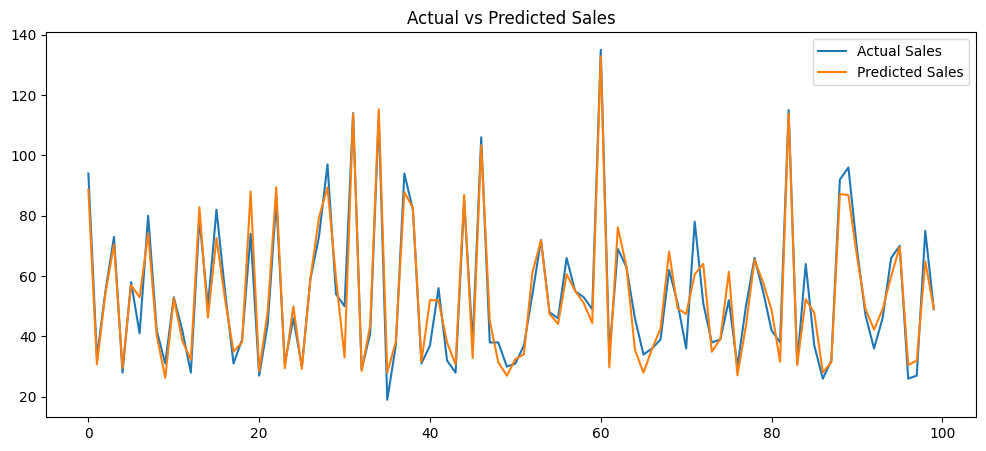

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:100], label="Actual Sales")
plt.plot(y_pred[:100], label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

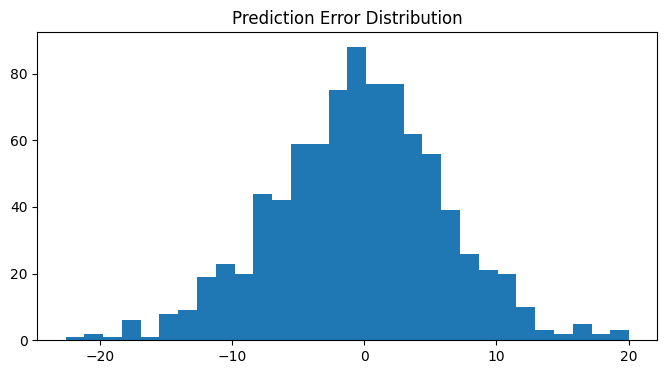

In [39]:
errors = y_test - y_pred

plt.figure(figsize=(8,4))
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.show()

In [40]:
df_inv_sample = df_inv.copy()

df_inv_sample["Inventory_Status"] = df_inv_sample["Prediction"].apply(
    lambda x: "LOW STOCK RISK" if x > avg_demand * 1.2 else "SAFE"
)

df_inv_sample["Inventory_Status"].value_counts()

Inventory_Status
SAFE              3126
LOW STOCK RISK    1170
Name: count, dtype: int64

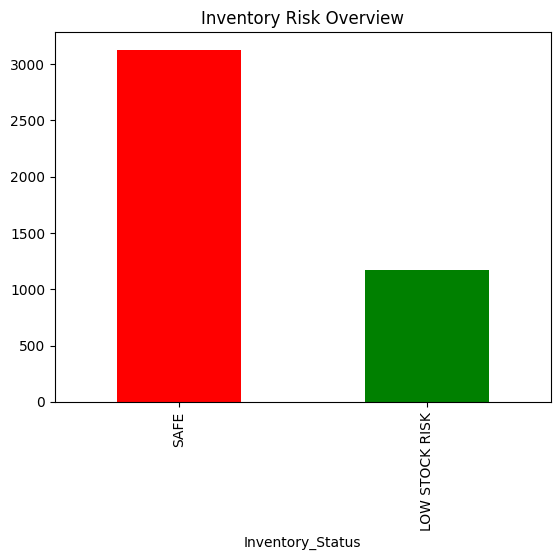

In [41]:
summary = df_inv_sample["Inventory_Status"].value_counts()

summary.plot(kind="bar", color=["red", "green"])
plt.title("Inventory Risk Overview")
plt.show()